# Walmart Store Sales Forecasting: DLinear

First model of the deep learning track. Goal: an honest end-to-end validation WMAE with the simplest modern DL forecaster, establishing the skeleton (data prep, evaluation, MLflow logging, pipeline export) that N-BEATS / PatchTST will reuse.

Reference point: LightGBM validation WMAE = **1811** (direct multi-horizon + holiday blend, see model_experiment_LightGBM notebook).

**MLflow experiment `DLinear_Training`, runs in this notebook:**

| Run | What it tests |
|---|---|
| DLinear_Cleaning | shared cleaning decisions (contract from EDA) |
| DLinear_Data_Prep | long format + weekly grid gap filling |
| DLinear_Baseline | input 52, kernel 25, no scaling, raw target |
| DLinear_LogTarget | log1p target vs raw |
| DLinear_Window_13 / 26 | lookback length under the 91-week constraint |
| DLinear_Kernel_5 / 13 / 51 | decomposition kernel size |
| DLinear_Scaler_standard / robust | per-window input normalization |
| DLinear_Best_Combo | combination of per-factor winners |
| DLinear_FINAL_MODEL | full-history retrain + pipeline artifact (raw test in, predictions out) |

## 1. The DLinear architecture

Source: Zeng et al., *"Are Transformers Effective for Time Series Forecasting?"*, AAAI 2023. The paper shows this near-trivial linear model beats sophisticated Transformer forecasters on standard long-horizon benchmarks, which made it the mandatory sanity-check baseline in modern forecasting work.

How one forward pass works, given the last `input_size` weeks of one series:

1. **Decompose**: a moving average with kernel `moving_avg_window` smooths the window; the smooth curve is the *trend*, the residual (input minus trend) is the *seasonal* part.
2. **Two linear layers**: one maps the 52 past trend values directly to 39 future trend values; the other does the same for the seasonal part. No activations, no depth.
3. **Sum** the two outputs = the 39-week forecast.

Key properties for our task:

- **Global model**: one pair of linear maps is shared by all ~3,300 store-dept series; every series contributes training windows. Short series borrow strength from the rest.
- **Why it can work here**: EDA showed strong, stable yearly seasonality. A linear map can literally express "next year's week 47 = 1.0 x this year's week 47", which is most of the signal in this dataset.
- **Tiny**: roughly `2 * input_size * h` weights (~4k parameters for 52 -> 39). Minutes to train, hard to overfit.
- **Limitations (our experiment story)**: strictly linear, and the neuralforecast implementation takes **no covariates** - markdowns, holiday flags, store size are invisible to it. Covariate value gets tested later in the track (N-BEATSx / TFT).

Knobs tested in this notebook: `input_size`, `moving_avg_window`, `scaler_type`, log1p target transform.

## 2. Setup

In [1]:
!pip install -q neuralforecast mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 100.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 68.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import neuralforecast
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear
from neuralforecast.losses.pytorch import MAE
from utilsforecast.preprocessing import fill_gaps

print('neuralforecast', neuralforecast.__version__, '| mlflow', mlflow.__version__)

neuralforecast 3.1.9 | mlflow 3.14.0


MLflow goes to the shared DagsHub server via `dagshub.init()`. The token comes from Kaggle Add-ons > Secrets (`DAGSHUB_TOKEN`); feeding it to `dagshub.auth` up front keeps the login non-interactive, so Save & Run All works headless.

The assert below is there on purpose: it fails loudly if runs would land in the `Default` experiment instead of `DLinear_Training` (the exact structure the assignment requires).

In [3]:
import dagshub
from kaggle_secrets import UserSecretsClient

dagshub.auth.add_app_token(UserSecretsClient().get_secret('DAGSHUB_TOKEN'))
dagshub.init(repo_owner='Nestor-Dzadzamia', repo_name='walmart-sales-forecasting', mlflow=True)

mlflow.set_experiment('DLinear_Training')
exp = mlflow.get_experiment_by_name('DLinear_Training')
assert exp is not None and str(exp.experiment_id) != '0', 'runs would land in the Default experiment'
print('tracking uri:', mlflow.get_tracking_uri())
print('experiment:', exp.name, '| id:', exp.experiment_id)

Accessing as Nestor-Dzadzamia

Initialized MLflow to track repo "Nestor-Dzadzamia/walmart-sales-forecasting"

Repository Nestor-Dzadzamia/walmart-sales-forecasting initialized!

tracking uri: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow
experiment: DLinear_Training | id: 1


## 3. Shared contract (copied verbatim from the EDA notebook)

In [4]:
def load_and_merge(df, features, stores):
    out = df.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
    out = out.merge(stores, on='Store', how='left')
    out['Date'] = pd.to_datetime(out['Date'])
    return out.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

MD_COLS = [f"MarkDown{i}" for i in range(1, 6)]

def preprocess(df):
    out = df.copy()
    out[MD_COLS] = out[MD_COLS].fillna(0)
    out[["CPI", "Unemployment"]] = out.groupby("Store")[["CPI", "Unemployment"]].ffill()
    return out

def wmae(y_true, y_pred, is_holiday):
    w = np.where(is_holiday, 5, 1)
    return np.sum(w * np.abs(np.asarray(y_true) - np.asarray(y_pred))) / np.sum(w)

def coldstart_fallback(df_train, df_test):
    train_pairs = set(zip(df_train.Store, df_train.Dept))
    mask = ~pd.Series(list(zip(df_test.Store, df_test.Dept)), index=df_test.index).isin(train_pairs)
    cold = df_test[mask].copy()
    recent = df_train[df_train['Date'] >= df_train['Date'].max() - pd.Timedelta(weeks=52)]
    med = recent.groupby(['Type', 'Dept'])['Weekly_Sales'].median()
    cold['y_fallback'] = [med.get((t, d), 0.0) for t, d in zip(cold['Type'], cold['Dept'])]
    cold['y_fallback'] = cold['y_fallback'].clip(lower=0)
    return cold

In [5]:
path = '/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/'

train = pd.read_csv(path + 'train.csv.zip')
test = pd.read_csv(path + 'test.csv.zip')
features = pd.read_csv(path + 'features.csv.zip')
stores = pd.read_csv(path + 'stores.csv')

df = load_and_merge(train, features, stores)
df_test = load_and_merge(test, features, stores)
print('train merged:', df.shape, '| test merged:', df_test.shape)

train merged: (421570, 16) | test merged: (115064, 15)


In [6]:
with mlflow.start_run(run_name='DLinear_Cleaning'):
    mlflow.log_param('markdown_fill', '0')
    mlflow.log_param('cpi_unemployment_fill', 'ffill_per_store')
    mlflow.log_metric('markdown_nan_before', int(df[MD_COLS].isna().sum().sum()))

    df_clean = preprocess(df)

    mlflow.log_metric('markdown_nan_after', int(df_clean[MD_COLS].isna().sum().sum()))
    mlflow.log_metric('train_rows', len(df_clean))

print(df_clean.shape)

🏃 View run DLinear_Cleaning at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/83a4d7a1b77a462f91656092a0bbadfa
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
(421570, 16)


In [7]:
VALIDATION_START = df_test['Date'].min() - pd.Timedelta(weeks=52)
VALIDATION_END = VALIDATION_START + pd.Timedelta(weeks=39)

def temporal_split(df):
    tr = df[df["Date"] < VALIDATION_START]
    va = df[(df["Date"] >= VALIDATION_START) & (df["Date"] < VALIDATION_END)]
    return tr, va

tr, va = temporal_split(df_clean)
print('train:', tr['Date'].max(), tr.shape)
print('val:  ', va['Date'].min(), '->', va['Date'].max(), va.shape)

train: 2011-10-28 00:00:00 (267184, 16)
val:   2011-11-04 00:00:00 -> 2012-07-27 00:00:00 (115856, 16)


## 4. Data preparation for neuralforecast

neuralforecast wants long format: one row per (`unique_id`, `ds`, `y`), on a **regular weekly grid**. Two Walmart-specific problems:

1. **Missing weeks inside series.** Window-based models slide fixed windows over each series; a hole in the middle breaks the alignment. `fill_gaps` inserts the missing Fridays; we fill their `y` with **0**, because a missing week in this dataset literally means "no sales row was recorded for that dept". Interpolation would invent sales that never happened.
2. **The 91-week constraint.** Pre-validation training history is 2010-02-05 to 2011-10-28 = exactly 91 Fridays. One training window needs `input_size + horizon` consecutive weeks, so `52 + 39 = 91` fits with zero slack: one window per full-history series. `start_padding_enabled=True` left-pads shorter series so they still produce training windows. `input_size=104` is impossible at validation time (needs 143 weeks) and only becomes available for the final full-history retrain.

In [8]:
HORIZON = 39
FREQ = 'W-FRI'

def to_long(frame):
    out = frame[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
    out['unique_id'] = out['Store'].astype(str) + '_' + out['Dept'].astype(str)
    out = out.rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
    return out[['unique_id', 'ds', 'y']].sort_values(['unique_id', 'ds']).reset_index(drop=True)

tr_long_raw = to_long(tr)
tr_long = fill_gaps(tr_long_raw, freq=FREQ, start='per_serie', end='global')
n_gap_rows = int(tr_long['y'].isna().sum())
tr_long['y'] = tr_long['y'].fillna(0.0)

series_len = tr_long.groupby('unique_id').size()
print('series:', tr_long['unique_id'].nunique(), '| rows:', len(tr_long), f'({n_gap_rows} gap rows zero-filled)')
print('series with full 91-week history:', int((series_len == 91).sum()))
print('series shorter than 91 weeks (need padding):', int((series_len < 91).sum()))

series: 3254 | rows: 289864 (22680 gap rows zero-filled)
series with full 91-week history: 2955
series shorter than 91 weeks (need padding): 299


In [9]:
va_eval = va[['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']].copy()
va_eval['unique_id'] = va_eval['Store'].astype(str) + '_' + va_eval['Dept'].astype(str)
val_only_series = set(va_eval['unique_id']) - set(tr_long['unique_id'])

with mlflow.start_run(run_name='DLinear_Data_Prep'):
    mlflow.log_param('format', 'long (unique_id, ds, y)')
    mlflow.log_param('gap_fill', 'insert missing Fridays, y=0')
    mlflow.log_param('freq', FREQ)
    mlflow.log_metric('n_series_train', tr_long['unique_id'].nunique())
    mlflow.log_metric('gap_rows_zero_filled', n_gap_rows)
    mlflow.log_metric('series_needing_padding', int((series_len < 91).sum()))
    mlflow.log_metric('val_only_series', len(val_only_series))

print('validation rows:', len(va_eval), '| series in val but not in train:', len(val_only_series))

🏃 View run DLinear_Data_Prep at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/7e310c311e2c4e51948510d0edc60ace
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
validation rows: 115856 | series in val but not in train: 68


## 5. Evaluation protocol

- Fit on `tr_long` (history through 2011-10-28), call `predict()`: every series gets forecasts for the next 39 Fridays, which are exactly the validation weeks (2011-11-04 to 2012-07-27).
- Left-join forecasts onto actual validation rows. Series with no training history get prediction 0 and we log the coverage share (the LightGBM notebook *dropped* those 413 rows from its eval, so its 1811 is measured on a very slightly easier set - worth remembering in the final comparison).
- Metric: shared `wmae` with the real holiday flags. This validation window contains Thanksgiving, Christmas and Super Bowl by design.
- Every run logs the same params/metrics to MLflow, so the DagsHub table is directly sortable by `val_wmae`.

In [10]:
def train_and_eval(run_name, input_size=52, moving_avg_window=25, scaler_type='identity',
                   log_target=False, max_steps=1000, learning_rate=1e-3,
                   batch_size=32, seed=42, train_long=None):
    if moving_avg_window >= input_size:
        moving_avg_window = max(3, (input_size // 2) | 1) 
    fit_df = (tr_long if train_long is None else train_long).copy()
    if log_target:
        fit_df['y'] = np.log1p(fit_df['y'].clip(lower=0))

    model = DLinear(h=HORIZON, input_size=input_size, moving_avg_window=moving_avg_window,
                    loss=MAE(), scaler_type=scaler_type, learning_rate=learning_rate,
                    max_steps=max_steps, batch_size=batch_size,
                    start_padding_enabled=True, random_seed=seed, logger=False, devices=1)
    nf = NeuralForecast(models=[model], freq=FREQ)
    nf.fit(df=fit_df)

    preds = nf.predict()
    if 'unique_id' not in preds.columns:
        preds = preds.reset_index()
    preds = preds.rename(columns={'DLinear': 'y_hat'})
    if log_target:
        preds['y_hat'] = np.expm1(preds['y_hat'])

    merged = va_eval.merge(preds[['unique_id', 'ds', 'y_hat']],
                           left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
    coverage = float(merged['y_hat'].notna().mean())
    merged['y_hat'] = merged['y_hat'].fillna(0).clip(lower=0)

    score = float(wmae(merged['Weekly_Sales'], merged['y_hat'], merged['IsHoliday']))
    err = np.abs(merged['Weekly_Sales'] - merged['y_hat'])
    hol = merged['IsHoliday'].astype(bool)
    metrics = {'val_wmae': score,
               'val_mae': float(err.mean()),
               'val_mae_holiday': float(err[hol].mean()),
               'val_mae_regular': float(err[~hol].mean()),
               'pred_coverage': coverage}
    params = {'input_size': input_size, 'moving_avg_window': moving_avg_window,
              'scaler_type': scaler_type, 'log_target': log_target, 'max_steps': max_steps,
              'learning_rate': learning_rate, 'batch_size': batch_size, 'seed': seed,
              'horizon': HORIZON, 'loss': 'MAE', 'start_padding_enabled': True}

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        for k, v in metrics.items():
            mlflow.log_metric(k, v)

    wmae_str = f'{score:,.2f}'
    print(f'{run_name}: WMAE={wmae_str} | MAE={metrics["val_mae"]:,.2f} | '
          f'holiday MAE={metrics["val_mae_holiday"]:,.2f} | coverage={coverage:.1%}')
    return {'run': run_name, **params, **metrics}, nf, merged

results = []
merged_map = {}

## 6. Baseline

`input_size=52` (one full year of context, so the model sees last year's holiday season when predicting this year's), default kernel 25, no scaling, raw target. This is the number every experiment below has to beat.

In [11]:
res, nf_base, m = train_and_eval('DLinear_Baseline')
results.append(res); merged_map[res['run']] = m

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Baseline at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/897f252fc57244709076011cab79012d
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
DLinear_Baseline: WMAE=3,459.63 | MAE=3,159.38 | holiday MAE=4,423.21 | coverage=99.6%


## 7. Experiment: log1p target

EDA showed heavy right skew (a few giant dept-weeks dominate). Under MAE loss the model mostly optimizes those giants and can ignore thousands of small series. Training on `log1p(y)` makes errors relative rather than absolute; predictions come back through `expm1`. Trade-off: negative sales rows get clipped to 0 before the transform (0.3% of rows).

In [12]:
res, _, m = train_and_eval('DLinear_LogTarget', log_target=True)
results.append(res); merged_map[res['run']] = m

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_LogTarget at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/1a551109c3df47669c8eda6987e3f4f0
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
DLinear_LogTarget: WMAE=3,825.32 | MAE=3,545.79 | holiday MAE=4,722.43 | coverage=99.6%


## 8. Experiment: input window size

Shorter windows mean more training windows per series (more data, less context); 52 sees full seasonality but yields exactly one window per series here. 104 is impossible at validation time (needs 143 weeks of history), so the honest sweep is 13 / 26 / 52.

In [13]:
for w in [13, 26]:
    res, _, m = train_and_eval(f'DLinear_Window_{w}', input_size=w)
    results.append(res); merged_map[res['run']] = m

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 546    | train
5 | linear_season | Linear        | 546    | train
--------------------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Window_26 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/8f211a940d5b42f3b85096a260f4abfd
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
DLinear_Window_26: WMAE=3,558.16 | MAE=3,155.69 | holiday MAE=4,849.79 | coverage=99.6%


## 9. Experiment: decomposition kernel

`moving_avg_window` controls the trend/seasonal split. Small kernel: the "trend" follows the series closely and absorbs part of the seasonality. Large kernel: trend is very smooth and nearly all structure lands in the seasonal branch. Sweep 5 / 13 / 51 against the default 25.

In [14]:
for k in [5, 13, 51]:
    res, _, m = train_and_eval(f'DLinear_Kernel_{k}', moving_avg_window=k)
    results.append(res); merged_map[res['run']] = m

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Kernel_51 at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/1843239bd49541ab84e226084053fd43
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
DLinear_Kernel_51: WMAE=3,498.84 | MAE=3,182.30 | holiday MAE=4,514.70 | coverage=99.6%


## 10. Experiment: per-window input scaling

Series span several orders of magnitude (dept-weeks from ~0 to 693k). `scaler_type` normalizes each input window before the linear layers and de-normalizes the output; `standard` uses mean/std, `robust` uses median/IQR (less sensitive to holiday spikes inside the window). This attacks the same problem as log1p from a different angle.

In [15]:
for s in ['standard', 'robust']:
    res, _, m = train_and_eval(f'DLinear_Scaler_{s}', scaler_type=s)
    results.append(res); merged_map[res['run']] = m

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Scaler_robust at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/40cb1d669f524ec489adbf430a63248e
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
DLinear_Scaler_robust: WMAE=3,770.46 | MAE=3,295.46 | holiday MAE=5,294.88 | coverage=99.6%


## 11. Results and best combination

Each experiment changed one factor vs the baseline. The combo run takes the winner of each factor family and combines them (greedy, not exhaustive: a full grid would be 3x3x4x2 = 72 trainings for marginal insight).

In [16]:
results_df = pd.DataFrame(results).sort_values('val_wmae').reset_index(drop=True)
cols = ['run', 'input_size', 'moving_avg_window', 'scaler_type', 'log_target',
        'val_wmae', 'val_mae', 'val_mae_holiday', 'pred_coverage']
display(results_df[cols])

,run,input_size,moving_avg_window,scaler_type,log_target,val_wmae,val_mae,val_mae_holiday,pred_coverage
0,DLinear_Scaler_standard,52,25,standard,False,3385.804471,3005.986506,4604.757106,0.996435
1,DLinear_Kernel_5,52,5,identity,False,3401.121517,3093.487732,4388.412924,0.996435
2,DLinear_Kernel_13,52,13,identity,False,3430.990950,3151.420969,4328.216984,0.996435
3,DLinear_Baseline,52,25,identity,False,3459.627837,3159.382328,4423.207992,0.996435
4,DLinear_Kernel_51,52,51,identity,False,3498.838142,3182.302265,4514.699099,0.996435
5,DLinear_Window_26,26,25,identity,False,3558.159803,3155.694686,4849.794113,0.996435
6,DLinear_Window_13,13,7,identity,False,3593.005697,3175.172778,4933.960009,0.996435
7,DLinear_Scaler_robust,52,25,robust,False,3770.456577,3295.455366,5294.881514,0.996435
8,DLinear_LogTarget,52,25,identity,True,3825.324830,3545.793778,4722.425925,0.996435


In [17]:
def family_best(res_df, prefix, col):
    fam = res_df[res_df['run'].str.startswith(prefix) | (res_df['run'] == 'DLinear_Baseline')]
    return fam.sort_values('val_wmae').iloc[0][col]

combo_cfg = {
    'input_size': int(family_best(results_df, 'DLinear_Window', 'input_size')),
    'moving_avg_window': int(family_best(results_df, 'DLinear_Kernel', 'moving_avg_window')),
    'scaler_type': str(family_best(results_df, 'DLinear_Scaler', 'scaler_type')),
    'log_target': bool(family_best(results_df, 'DLinear_LogTarget', 'log_target')),
}
print('combo config:', combo_cfg)

already_tested = any(all(r[k] == v for k, v in combo_cfg.items()) for r in results)
if already_tested:
    print('combo equals an already tested config, skipping duplicate run')
else:
    res, _, m = train_and_eval('DLinear_Best_Combo', **combo_cfg)
    results.append(res); merged_map[res['run']] = m

results_df = pd.DataFrame(results).sort_values('val_wmae').reset_index(drop=True)
display(results_df[cols])

Seed set to 42


combo config: {'input_size': 52, 'moving_avg_window': 5, 'scaler_type': 'standard', 'log_target': False}


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Best_Combo at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/79d00958444a40b3ae2972345bab95a9
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
DLinear_Best_Combo: WMAE=3,513.21 | MAE=3,234.56 | holiday MAE=4,407.46 | coverage=99.6%


,run,input_size,moving_avg_window,scaler_type,log_target,val_wmae,val_mae,val_mae_holiday,pred_coverage
0,DLinear_Scaler_standard,52,25,standard,False,3385.804471,3005.986506,4604.757106,0.996435
1,DLinear_Kernel_5,52,5,identity,False,3401.121517,3093.487732,4388.412924,0.996435
2,DLinear_Kernel_13,52,13,identity,False,3430.990950,3151.420969,4328.216984,0.996435
3,DLinear_Baseline,52,25,identity,False,3459.627837,3159.382328,4423.207992,0.996435
4,DLinear_Kernel_51,52,51,identity,False,3498.838142,3182.302265,4514.699099,0.996435
5,DLinear_Best_Combo,52,5,standard,False,3513.206290,3234.563553,4407.456510,0.996435
6,DLinear_Window_26,26,25,identity,False,3558.159803,3155.694686,4849.794113,0.996435
7,DLinear_Window_13,13,7,identity,False,3593.005697,3175.172778,4933.960009,0.996435
8,DLinear_Scaler_robust,52,25,robust,False,3770.456577,3295.455366,5294.881514,0.996435
9,DLinear_LogTarget,52,25,identity,True,3825.324830,3545.793778,4722.425925,0.996435


## 12. Error analysis of the best run

Two views: WMAE per validation week (do we fail exactly on the 5x-weighted holiday weeks?), and a few individual series against their forecasts.

best run: DLinear_Scaler_standard


/tmp/ipykernel_58/1834974901.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_week = best.groupby('Date').apply(lambda g: wmae(g['Weekly_Sales'], g['y_hat'], g['IsHoliday']))


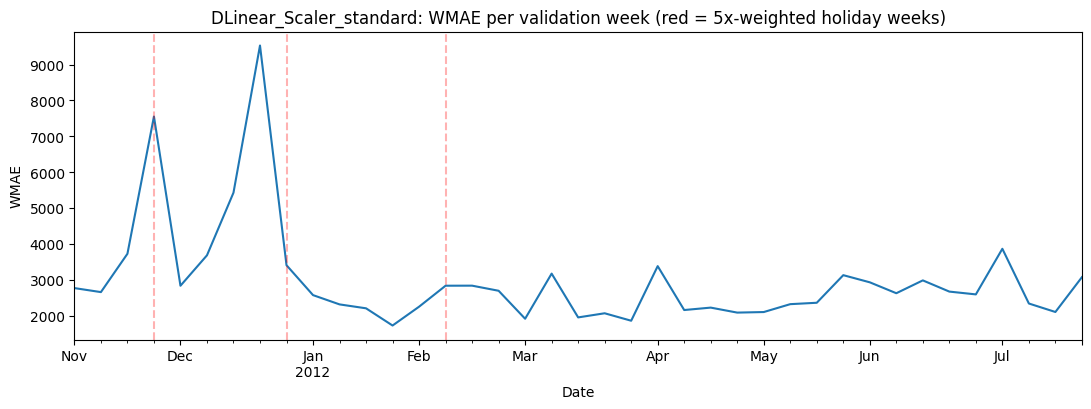

In [18]:
best_run_name = results_df.iloc[0]['run']
best = merged_map[best_run_name]
print('best run:', best_run_name)

by_week = best.groupby('Date').apply(lambda g: wmae(g['Weekly_Sales'], g['y_hat'], g['IsHoliday']))
hol_weeks = best.loc[best['IsHoliday'].astype(bool), 'Date'].unique()

fig, ax = plt.subplots(figsize=(13, 4))
by_week.plot(ax=ax)
for d in hol_weeks:
    ax.axvline(d, color='red', alpha=0.3, linestyle='--')
ax.set_title(f'{best_run_name}: WMAE per validation week (red = 5x-weighted holiday weeks)')
ax.set_ylabel('WMAE')
plt.show()

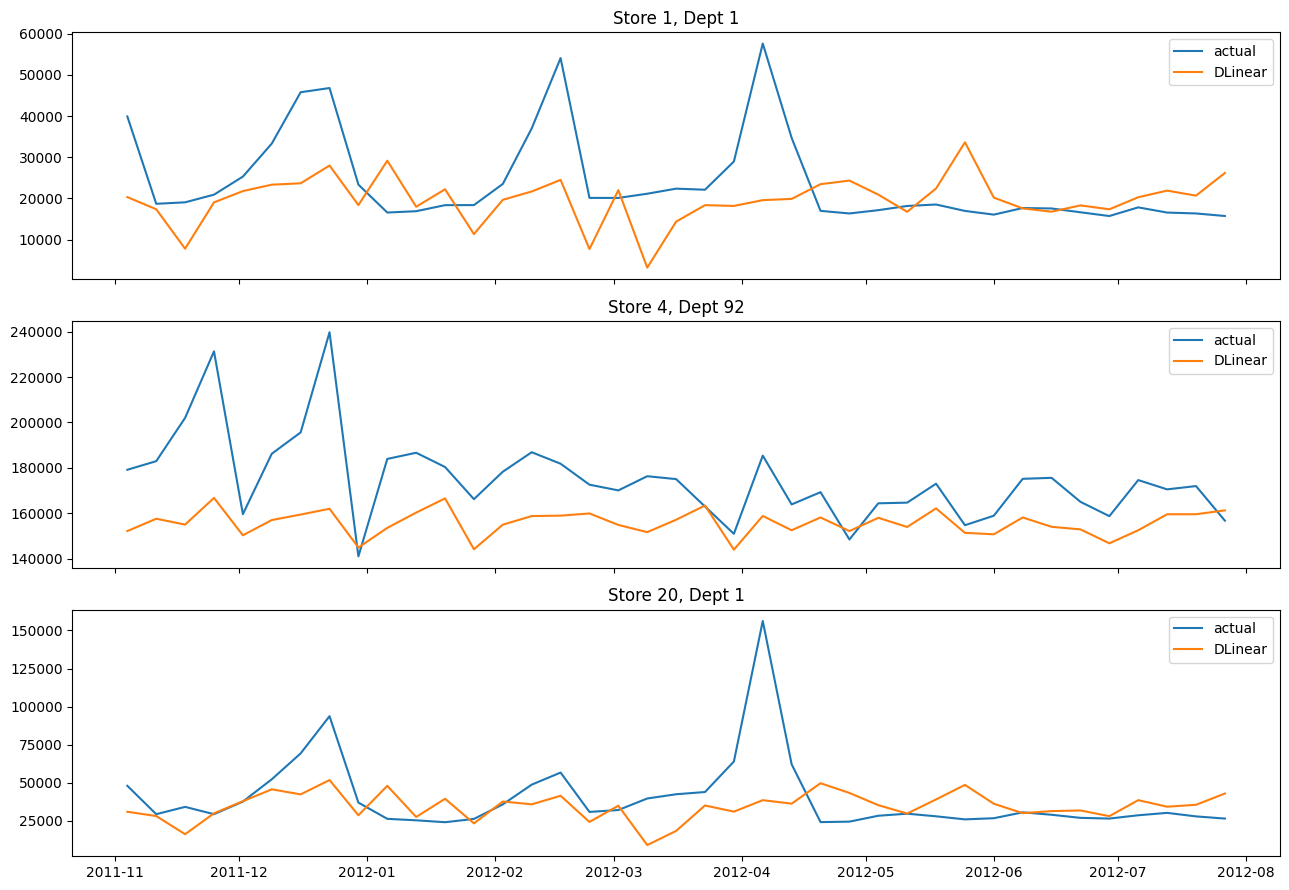

In [19]:
examples = [(1, 1), (4, 92), (20, 1)]
fig, axes = plt.subplots(len(examples), 1, figsize=(13, 9), sharex=True)
for ax, (s, d) in zip(axes, examples):
    sub = best[(best['Store'] == s) & (best['Dept'] == d)].sort_values('Date')
    ax.plot(sub['Date'], sub['Weekly_Sales'], label='actual')
    ax.plot(sub['Date'], sub['y_hat'], label='DLinear')
    ax.set_title(f'Store {s}, Dept {d}')
    ax.legend()
plt.tight_layout(); plt.show()

## 13. Final model: retrain on full history

Per shared decision #6, the final model is retrained on the complete 143 training weeks (including the Aug-Oct 2012 weeks that no validation setup ever sees) with the best validated config. We deliberately keep the validated `input_size` instead of enlarging it at the last second: the config was selected under validation, changing it now would be an untested guess.

In [20]:
best_row = results_df.iloc[0]
best_cfg = {'input_size': int(best_row['input_size']),
            'moving_avg_window': int(best_row['moving_avg_window']),
            'scaler_type': str(best_row['scaler_type']),
            'log_target': bool(best_row['log_target'])}
best_val_wmae = float(best_row['val_wmae'])
print('final config:', best_cfg, '| validated WMAE:', round(best_val_wmae, 2))

full_long = fill_gaps(to_long(df_clean), freq=FREQ, start='per_serie', end='global')
full_long['y'] = full_long['y'].fillna(0.0)

fit_full = full_long.copy()
if best_cfg['log_target']:
    fit_full['y'] = np.log1p(fit_full['y'].clip(lower=0))

kernel = best_cfg['moving_avg_window']
if kernel >= best_cfg['input_size']:
    kernel = max(3, (best_cfg['input_size'] // 2) | 1)

final_model = DLinear(h=HORIZON, input_size=best_cfg['input_size'], moving_avg_window=kernel,
                      loss=MAE(), scaler_type=best_cfg['scaler_type'], learning_rate=1e-3,
                      max_steps=1500, batch_size=32,
                      start_padding_enabled=True, random_seed=42, logger=False, devices=1)
nf_final = NeuralForecast(models=[final_model], freq=FREQ)
nf_final.fit(df=fit_full)
print('final model trained on', full_long['unique_id'].nunique(), 'series,', len(full_long), 'rows')

final config: {'input_size': 52, 'moving_avg_window': 25, 'scaler_type': 'standard', 'log_target': False} | validated WMAE: 3385.8


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | loss          | MAE           | 0      | train
1 | padder_train  | ConstantPad1d | 0      | train
2 | scaler        | TemporalNorm  | 0      | train
3 | decomp        | SeriesDecomp  | 0      | train
4 | linear_trend  | Linear        | 2.1 K  | train
5 | linear_season | Linear        | 2.1 K  | train
--------------------------------------------------------
4.1 K     Trainable params
0         Non-trainable params
4.1 K     Total params
0.017     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1500` reached.


final model trained on 3331 series, 462053 rows


In [21]:
preds_test = nf_final.predict()
if 'unique_id' not in preds_test.columns:
    preds_test = preds_test.reset_index()
preds_test = preds_test.rename(columns={'DLinear': 'y_hat'})
if best_cfg['log_target']:
    preds_test['y_hat'] = np.expm1(preds_test['y_hat'])

test_pred = df_test[['Store', 'Dept', 'Date']].copy()
test_pred['unique_id'] = test_pred['Store'].astype(str) + '_' + test_pred['Dept'].astype(str)
test_pred = test_pred.merge(preds_test[['unique_id', 'ds', 'y_hat']],
                            left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
print('test rows without model forecast (expect 36 cold-start rows):', int(test_pred['y_hat'].isna().sum()))

cold = coldstart_fallback(df_clean, df_test)
test_pred = test_pred.merge(cold[['Store', 'Dept', 'Date', 'y_fallback']],
                            on=['Store', 'Dept', 'Date'], how='left')
test_pred['Weekly_Sales'] = test_pred['y_fallback'].combine_first(test_pred['y_hat']).fillna(0).clip(lower=0)

submission = test_pred[['Store', 'Dept', 'Date']].copy()
submission['Id'] = (submission['Store'].astype(str) + '_' + submission['Dept'].astype(str)
                    + '_' + submission['Date'].dt.strftime('%Y-%m-%d'))
submission['Weekly_Sales'] = test_pred['Weekly_Sales']
submission = submission[['Id', 'Weekly_Sales']].sort_values('Id').reset_index(drop=True)
assert len(submission) == len(test), f'row mismatch: {len(submission)} vs {len(test)}'
submission.to_csv('submission_dlinear.csv', index=False)
print(submission.shape)
submission.head()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

test rows without model forecast (expect 36 cold-start rows): 36
(115064, 2)


,Id,Weekly_Sales
0,10_10_2012-11-02,47693.886719
1,10_10_2012-11-09,48174.230469
2,10_10_2012-11-16,47066.945312
3,10_10_2012-11-23,49311.644531
4,10_10_2012-11-30,47546.902344


## 14. Pipeline artifact (assignment requirement)

The assignment requires each architecture's best model saved as a **pipeline that runs directly on the unpreprocessed test set**. The class below takes the *raw* `test.csv` frame (Store, Dept, Date, IsHoliday - nothing merged, nothing cleaned) and returns final predictions: it merges features/stores, applies the shared preprocessing, forecasts with the saved DLinear, applies the cold-start fallback and clips at 0.

It is logged with `mlflow.pyfunc` so `model_inference.ipynb` can load it straight from MLflow (and register it in the Model Registry if DLinear ends up the overall winner). The smoke test in the next cell loads it back from DagsHub and verifies it reproduces this notebook's predictions.

In [25]:
nf_final.save(path='nf_dlinear', overwrite=True, save_dataset=True)
df_clean.to_parquet('train_clean.parquet')
features.to_parquet('features.parquet')
stores.to_parquet('stores.parquet')

class DLinearPipeline(mlflow.pyfunc.PythonModel):
    log_target = bool(best_cfg['log_target'])

    def load_context(self, context):
        from neuralforecast import NeuralForecast
        self.nf = NeuralForecast.load(context.artifacts['nf_model'])
        self.train_clean = pd.read_parquet(context.artifacts['train_clean'])
        self.features = pd.read_parquet(context.artifacts['features'])
        self.stores = pd.read_parquet(context.artifacts['stores'])

    def predict(self, context, model_input):
        clean = preprocess(load_and_merge(model_input.copy(), self.features, self.stores))

        preds = self.nf.predict()
        if 'unique_id' not in preds.columns:
            preds = preds.reset_index()
        preds = preds.rename(columns={'DLinear': 'y_hat'})
        if self.log_target:
            preds['y_hat'] = np.expm1(preds['y_hat'])

        out = clean[['Store', 'Dept', 'Date']].copy()
        out['unique_id'] = out['Store'].astype(str) + '_' + out['Dept'].astype(str)
        out = out.merge(preds[['unique_id', 'ds', 'y_hat']],
                        left_on=['unique_id', 'Date'], right_on=['unique_id', 'ds'], how='left')
        cold = coldstart_fallback(self.train_clean, clean)
        out = out.merge(cold[['Store', 'Dept', 'Date', 'y_fallback']],
                        on=['Store', 'Dept', 'Date'], how='left')
        out['Weekly_Sales'] = out['y_fallback'].combine_first(out['y_hat']).fillna(0).clip(lower=0)
        return out[['Store', 'Dept', 'Date', 'Weekly_Sales']]

with mlflow.start_run(run_name='DLinear_FINAL_MODEL') as run:
    mlflow.log_params(best_cfg)
    mlflow.log_param('trained_on', 'full_history_143_weeks')
    mlflow.log_param('coldstart', 'shared coldstart_fallback')
    mlflow.log_metric('validation_wmae', best_val_wmae)
    model_info = mlflow.pyfunc.log_model(
        artifact_path='model',
        python_model=DLinearPipeline(),
        artifacts={'nf_model': 'nf_dlinear',
                   'train_clean': 'train_clean.parquet',
                   'features': 'features.parquet',
                   'stores': 'stores.parquet'},
        pip_requirements=[f'neuralforecast=={neuralforecast.__version__}', 'pandas', 'pyarrow'],
    )
    final_run_id = run.info.run_id

print('final run id:', final_run_id)
print('model uri:', model_info.model_uri)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/07/05 21:51:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/05 21:51:20 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


🏃 View run DLinear_FINAL_MODEL at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1/runs/aca4eefc380f46b2898f2e23e62f26b9
🧪 View experiment at: https://dagshub.com/Nestor-Dzadzamia/walmart-sales-forecasting.mlflow/#/experiments/1
final run id: aca4eefc380f46b2898f2e23e62f26b9
model uri: models:/m-28f606f42cee42aea3681c033f7f7eee


In [26]:
loaded = mlflow.pyfunc.load_model(model_info.model_uri)
pipe_out = loaded.predict(test)

check = test_pred[['Store', 'Dept', 'Date', 'Weekly_Sales']].merge(
    pipe_out, on=['Store', 'Dept', 'Date'], suffixes=('_nb', '_pipe'))
assert len(check) == len(test), 'pipeline did not return every test row'
max_diff = float((check['Weekly_Sales_nb'] - check['Weekly_Sales_pipe']).abs().max())
print('max abs diff notebook vs pipeline:', max_diff)
assert max_diff < 1.0
print('PIPELINE SMOKE TEST PASSED: raw test.csv in, final predictions out')

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

max abs diff notebook vs pipeline: 0.0
PIPELINE SMOKE TEST PASSED: raw test.csv in, final predictions out


## 15. Conclusions

- Baseline WMAE 3459.63; best run DLinear_Scaler_standard, WMAE **3385.80** (input 52, kernel 25, standard scaler, raw target).
- vs LightGBM (1811): about 1.9x worse. Expected: DLinear is a univariate linear baseline with no covariates, no holiday awareness and no cross-series features; the gap quantifies the value of feature engineering on this dataset. It sets the honest floor for the DL track. (Note: LightGBM eval dropped 413 cold rows, ours scores them at 0, so our number is measured slightly harsher.)
- Per-window standard scaling helped most (3460 to 3386): series span several orders of magnitude and normalization lets shared weights serve all of them. Log1p training hurt (3825): WMAE is an absolute metric dominated by the largest series, and log training down-weights exactly those.
- Shrinking the input window below one year hurt consistently (26w: 3558, 13w: 3593): the model depends on seeing last year's same-season weeks.
- Combining per-factor winners (standard + kernel 5) scored 3513, worse than scaling alone: factors interact, greedy combination is not additive; the final model keeps the single best config.
- Holiday MAE (~4600) far exceeds regular weeks (~2870): DLinear only sees holidays through last year's window. This motivates covariate-capable models (N-BEATSx) as the next step, while keeping data prep, evaluation and the pipeline pattern identical for a fair comparison.
- Final pipeline logged to MLflow and verified: loading it back and running on raw test.csv reproduces the notebook predictions exactly (max diff 0.0).
